In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint
from scipy.optimize import least_squares, minimize
from ITIS_Model_funcs import get_nominal_param, ITIS, OLS_res
import pickle


In [68]:
paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']

In [69]:
param_log,IC = get_nominal_param()

##Define time spaces
tstart = 0
t_end =24*8
dt = .05
tspace = np.arange(tstart,t_end,dt)
tfinal = np.arange(0,24+dt,dt)

##Solve the model at nominal values
ode_options = {'rtol': 1e-6}
ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


# t_data = np.linspace(0,24,24+1) # time points every hour
# t_data = np.linspace(0,24,12+1) # less data, every 30 minutes

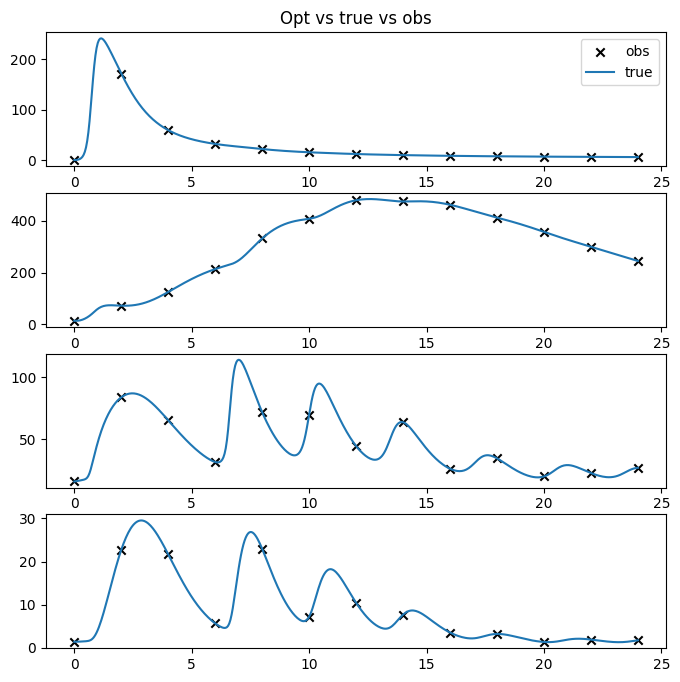

In [70]:
#Generate data

D = '3'         # '1' for ACTH + Cort,
                # '2' for ACTH + Cort + TNF-a
                # '3' for ACTH + Cort + TNF-a + IL10
dpoints = '2'   # '1' for 25, '2' for 13

if D == '1':
    output_ids = [6,7]
    param_ids = [33, 12, 36, 43, 32, 39, 7, 16, 31, 15, 37, 9, 8, 28, 14]
elif D == '2':
    output_ids = [3,6,7]
    param_ids = [33, 12, 36, 32, 7, 34, 31, 15, 8, 9, 16, 14, 28, 26, 1]
elif D == '3':
    output_ids = [3,4,6,7]
    param_ids = [12, 33, 7, 16, 36, 43, 39, 15, 32, 31, 22, 8, 9, 14, 21, 10, 1]


##use generated sets instead
with open('syntheticData\\TRUE_SOL' + D + dpoints + '.pkl', 'rb') as f:
    results = pickle.load(f)
y_data = results['y_data'].copy()
t_data = results['t_data'].copy()


plt.figure(figsize = (8,8))
for i in range(len(output_ids)):
    if i == 1:
        plt.title('Opt vs true vs obs')
        plt.legend()
    plt.subplot(4,1,i+1)
    plt.scatter(t_data,y_data[:,i],marker='x',color='k',label='obs')
    plt.plot(tfinal,true_sol[:,output_ids[i]],label='true')

plt.show()


In [71]:
# MJC - make these bounds based on the parameter values
UB = np.log(np.exp(param_log[param_ids])*10)
LB =  np.log(np.exp(param_log[param_ids])*0.001)


In [72]:
## We will do a global optimization here to see how close we can get to our true data generating
## parameters if we start at multiple locations in parameter space

num_samp  = 20
param_in  = np.zeros((num_samp,len(param_ids)))
param_opt = np.zeros((num_samp,len(param_ids)))
param_all = param_log.copy()
rel_err = np.zeros((num_samp,len(param_ids)))
opt_cost = np.zeros(num_samp) ##why do we only take a vector for this?

var = 0.25
for i in range(num_samp):
#
    param_in [i,:]= np.log(np.exp(param_log[param_ids])*np.random.normal(1,var,(1,len(param_ids))).flatten()) ##MESS WITH BOUNDS
##SAVE PERTURBATION AMOUNT
# Now, we set up a minimization problem
    least_sq_sol = least_squares(OLS_res,param_in[i,:],args=(y_data,t_data,param_ids,output_ids,param_all,IC_2),
                             bounds=(LB,UB),verbose=1,xtol=1e-8,diff_step=1e-4,max_nfev=200)
    param_opt[i,:] = least_sq_sol.x
    rel_err[i,:] = (np.exp(least_sq_sol.x) - np.exp(param_log[param_ids]))/np.exp(param_log[param_ids])
    opt_cost[i] = least_sq_sol.cost
    print(f"sample {i} relative error of solution {rel_err[i,:]}\n")
    print(f"sample {i} cost {opt_cost[i]}\n")
    





`xtol` termination condition is satisfied.
Function evaluations 39, initial cost 1.4761e+01, final cost 2.1723e-06, first-order optimality 2.53e-03.
sample 0 relative error of solution [-1.91690007e-02  9.35523975e-04 -3.22295083e-03 -3.23913216e-02
 -7.40807921e-04 -1.46713028e-04 -2.95893088e-04 -1.82854728e-01
 -8.53871365e-04  6.78452528e-04  1.78826586e-03  1.87064763e-01
  1.83312659e-01 -1.48739296e-01  7.63162421e-04  5.98914457e-04
  1.82161065e-03]

sample 0 cost 2.1723023866995877e-06

`xtol` termination condition is satisfied.
Function evaluations 38, initial cost 1.0595e+01, final cost 6.3408e-07, first-order optimality 2.96e-04.
sample 1 relative error of solution [-1.70462056e-03 -2.91131128e-04 -2.02833256e-03 -1.55430753e-03
  2.07689733e-04  4.54120028e-07  3.09483778e-05  3.34281095e-03
  4.40301413e-04 -6.37096641e-05  1.59324343e-03 -2.01505145e-01
 -2.12170856e-01  5.83833666e-03 -9.37728131e-04  3.60818990e-03
  1.71061329e-03]

sample 1 cost 6.340842248659932e-0

In [73]:
# Now generate the model outputs and plot the parameters
opt_solutions = np.zeros((num_samp,len(tfinal),len(output_ids)))
for i in range(num_samp):
    param_eval = param_log.copy()
    param_eval[param_ids] = param_opt[i,:]

    ##
    opt_model1 = odeint(ITIS, IC, tspace, args = (param_eval,), **ode_options)
    IC_2    = opt_model1[-1,:]
    IC_2[0] = 2.0
    # Resolve model only over 24 hours at subsampled time points. This will be used as our data
    opt_model = odeint(ITIS, IC_2, tfinal, args = (param_eval,), **ode_options)
    for j in range(len(output_ids)):
        opt_solutions[i,:,j] = opt_model[:,output_ids[j]]


ODE_sol = odeint(ITIS, IC, tspace, args = (param_log,), **ode_options)

# MJC - this is where we can specify that the infection begins during this final time point
IC_2    = ODE_sol[-1,:]
IC_2[0] = 2.0
# Resolve model only over 24 hours at subsampled time points. This will be used as our data
true_sol = odeint(ITIS, IC_2, tfinal, args = (param_log,), **ode_options)


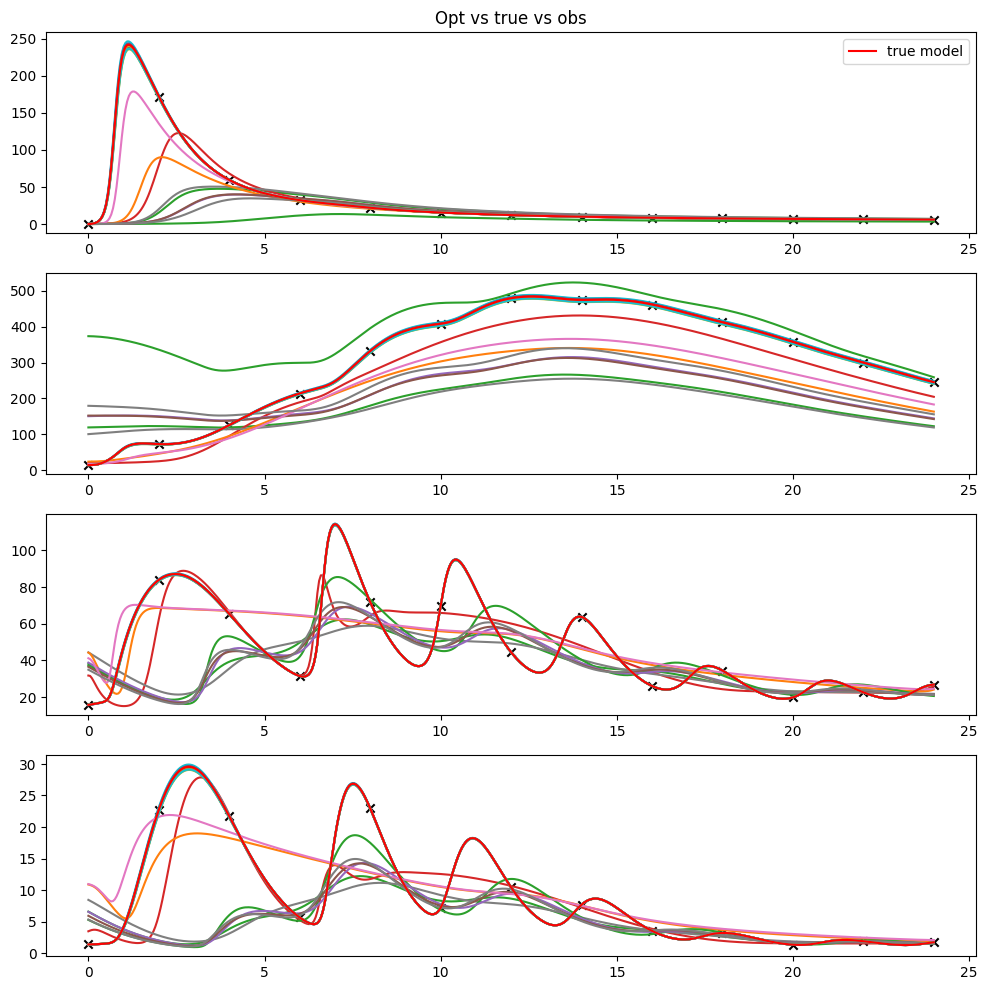

In [74]:

plt.figure(figsize = (12,12))

for i in range(len(output_ids)):
    if i == 1:
        plt.title('Opt vs true vs obs')
        plt.legend()
    plt.subplot(4,1,i+1)
    plt.scatter(t_data,y_data[:,i],marker='x',color='k')
    plt.plot(tfinal,opt_solutions[:,:,i].T)
    plt.plot(tfinal,true_sol[:,output_ids[i]],color='r',label='true model')

#plt.savefig("WLS_FIMSelection\\WLS_32.png")
plt.show()

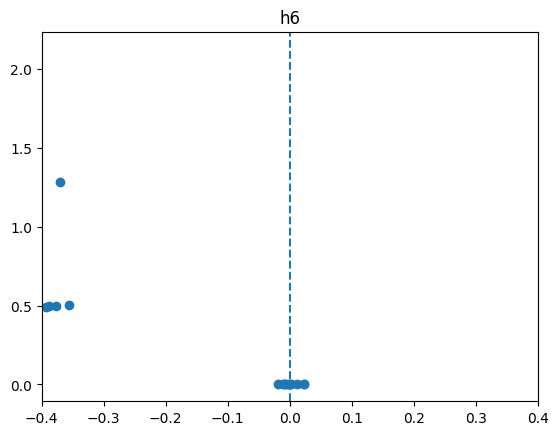

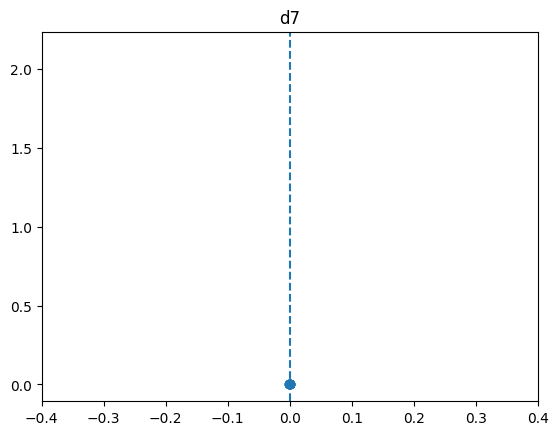

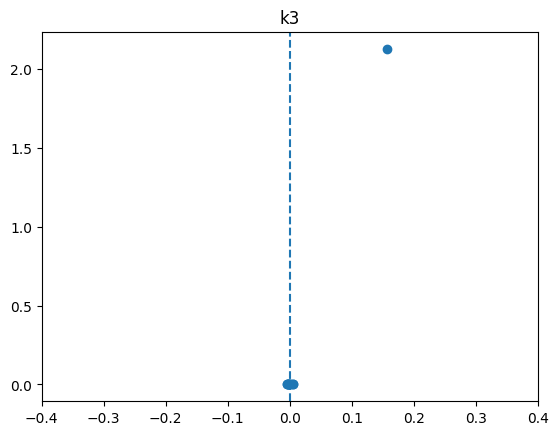

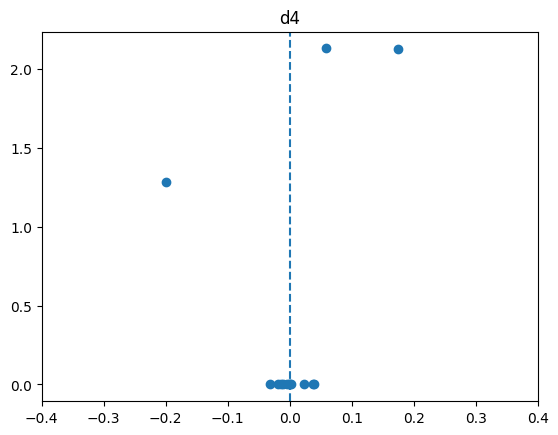

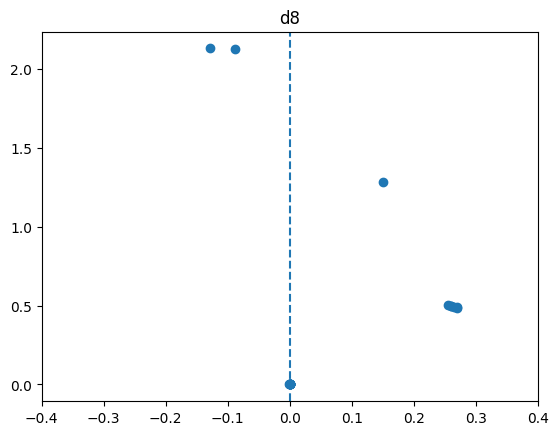

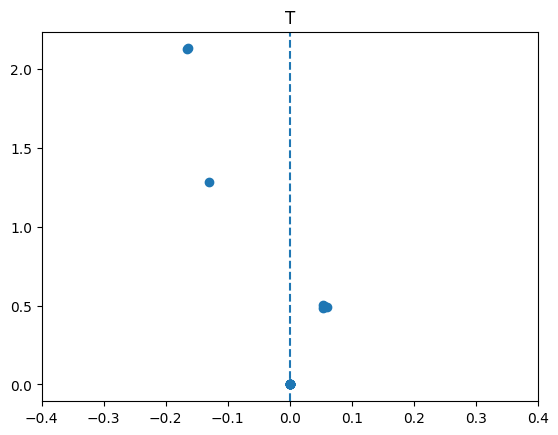

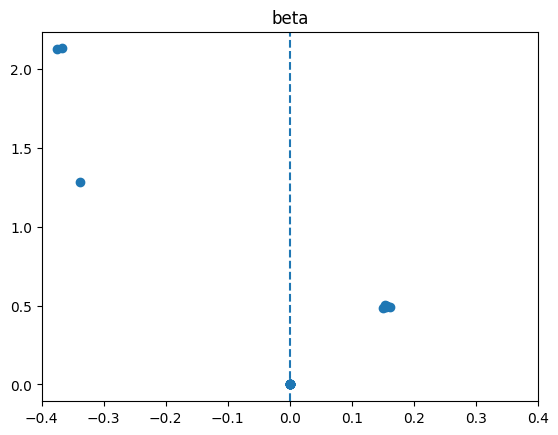

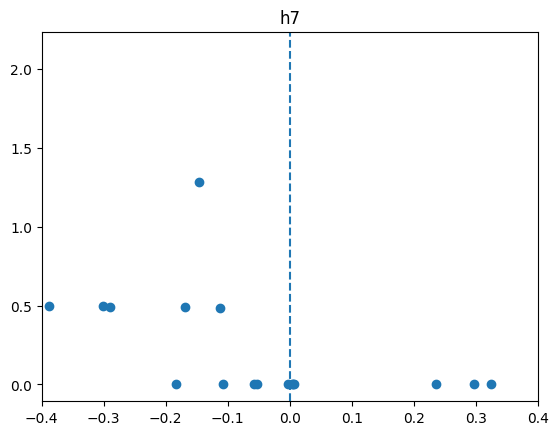

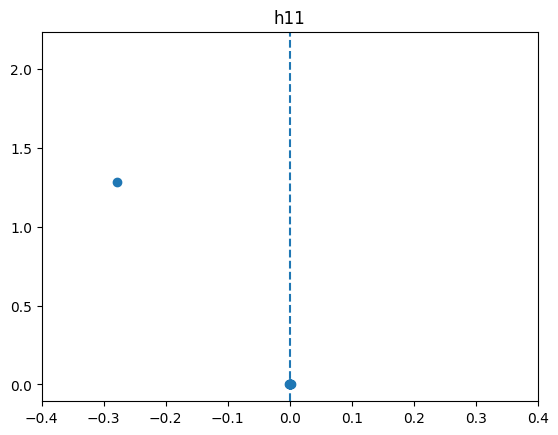

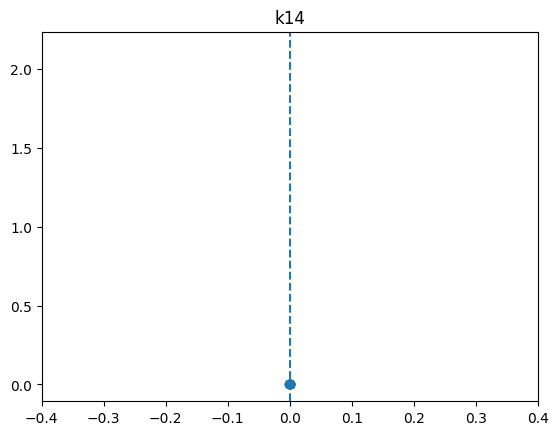

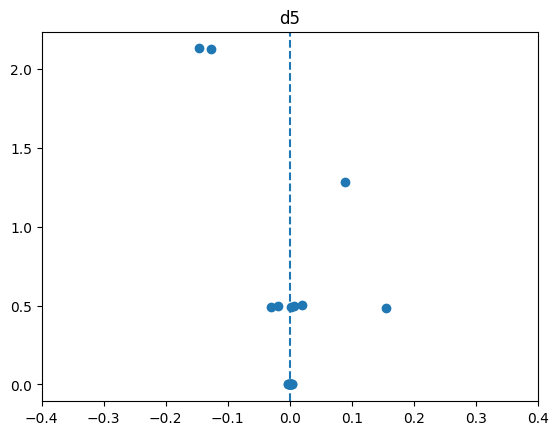

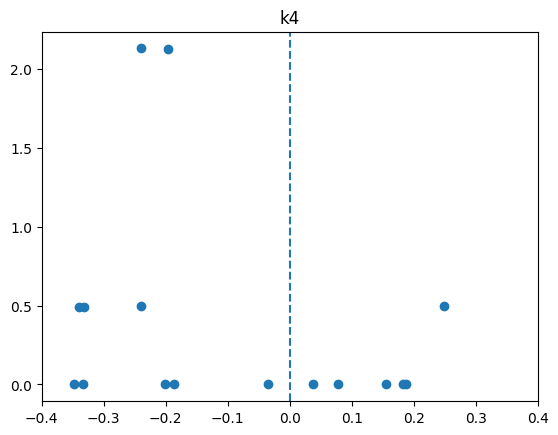

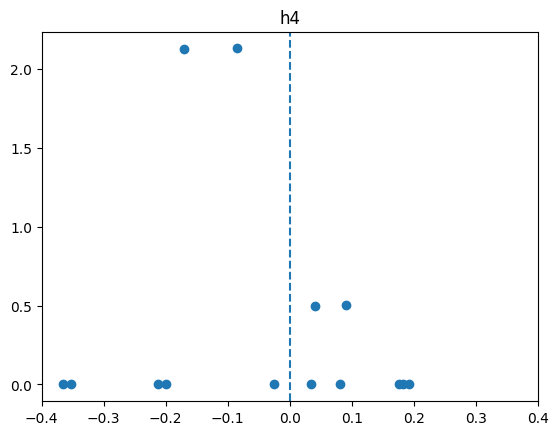

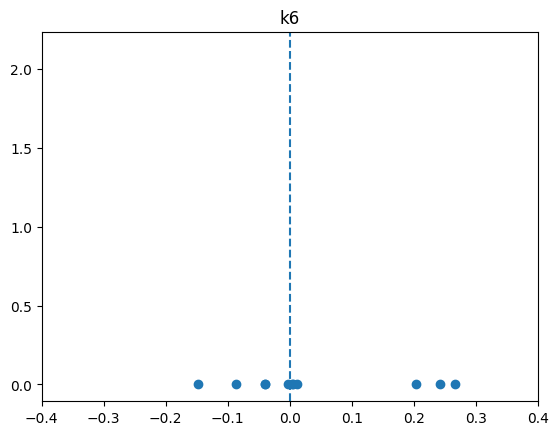

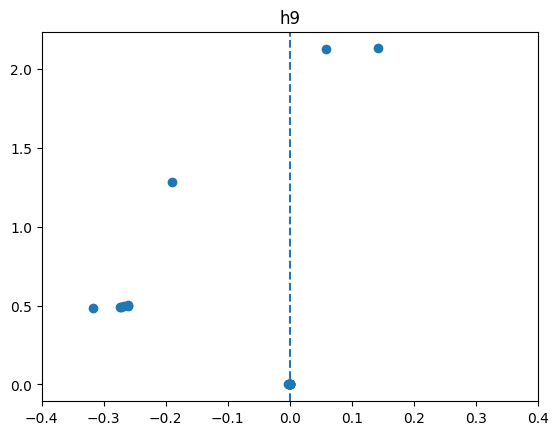

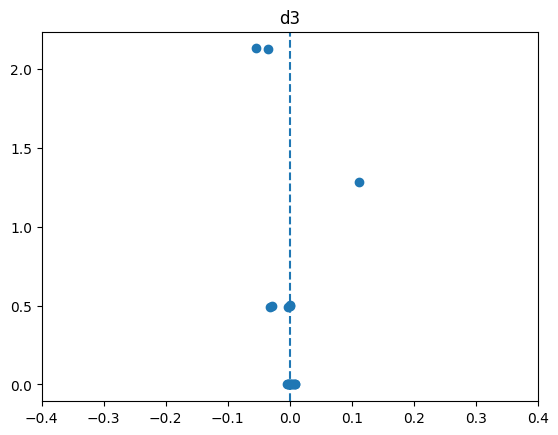

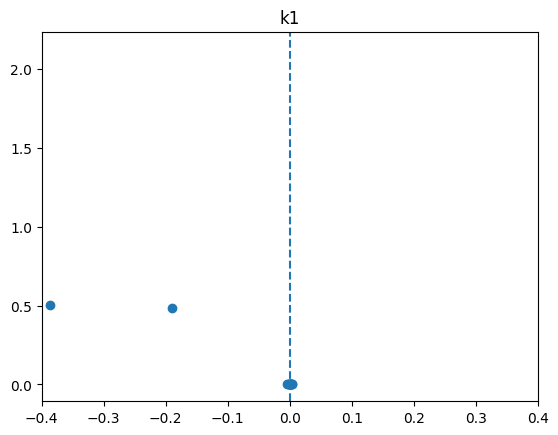

In [75]:
for i in range(len(param_ids)):
    plt.figure()
    # plt.scatter(param_opt[:,i],opt_cost,marker='o')
    # plt.axvline(param_log[param_ids[i]],linestyle='--')

    plt.scatter(rel_err[:,i],opt_cost,marker='o')
    plt.axvline(0,linestyle='--')
    plt.title(paramtitles[param_ids[i]])
    plt.xlim([-0.4,0.4])
    plt.show()
    ##WHY IS Y LIM THE SAME FOR EACH PLOT?

2109.082205695742


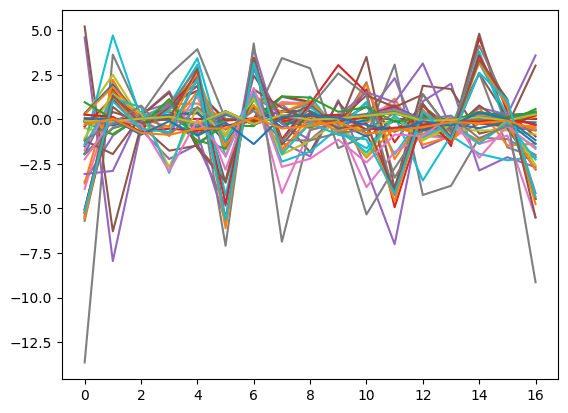

In [76]:
##SENSITIVITY ANALYSIS
h = 1e-6  #amount to perturb parameters
n_param = len(param_ids) #Just the parameters we optimize
n_states = len(output_ids)
which_opt_param = 2


param_sens_all = param_log.copy()
param_sens_all[param_ids] = param_opt[which_opt_param,:]
Sensitivity_Mat = np.zeros((n_param, len(t_data) * n_states))  ##Initialize shape of sensitivity matrix.
for i in range(n_param):  #calculate the relative sensitivity to each 45 parameters

        param_in = param_sens_all[param_ids[i]]
        param_delta = param_in + h ##    [HOW EXACTLY SHOULD I BE PERTURBING MY PARAM?]
        ##THIS THING NEXT DO THIS!!!
        Sensitivity_Mat[i, :] = ((1 / h) * (OLS_res(param_delta, y_data, t_data, param_ids[i], output_ids, param_sens_all, IC)
                                            - OLS_res(param_in, y_data, t_data, param_ids[i], output_ids, param_sens_all, IC)))

twonorms = np.zeros(n_param)

S_opt = Sensitivity_Mat.copy()
F_opt = S_opt@S_opt.T
print(np.linalg.cond(F_opt))

plt.figure()
plt.plot(S_opt)
plt.show()

for i in range(n_param):
        twonorms[i] = np.power(sum(np.power(Sensitivity_Mat[i, :], 2)), 1 / 2)


In [77]:
# #PLOTTING
# paramtitles = ['d1',
#                'k1', 'k2', 'h1', 'h2', 'h3', 'd2',
#                'k3', 'k4', 'h4', 'd3',
#                'h5', 'h6', 'k5', 'k6', 'h7', 'd4',
#                'b1', 'k7', 'h8', 'k8', 'h9', 'd5', 'h10',
#                'b2', 'k9', 'k10', 'k11', 'd6',
#                'k12', 'k13', 'k14', 'h11', 'd7',
#                'k15', 'k16', 'd8',
#                'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']
#
# statetitles = ["Endotoxin", "Phagocytes", "TGF-B", "TNF-a", "IL-10", "CRH", "ACTH", "Cortisol"]
# statetitles_Short = ['endo', 'phag', 'TGFB', 'TNF', 'IL10', 'CRH', 'ACTH', 'cort']
#
# fig, ax = plt.subplots(figsize = (15,5))
# selected_titles = [paramtitles[i] for i in param_ids]
# ax.bar(selected_titles,twonorms)
# plt.xlim(-0.9, len(param_ids) - 1 + 0.9)
#
# ##Plot in descending order
# data = sorted(zip(selected_titles, twonorms), key=lambda v: v[1], reverse = True)
#
# plt.figure(figsize=(15, 5))
# for (i, c) in data:  # unpack and plot each tuple in sorted order
#     bars = plt.bar(i, c, align='center', color = 'cyan')
# plt.xlim(-0.9, len(param_ids) - 1 + 0.9)
#
# #plt.savefig("WLS_FIMSelection\\Sens_WLS_32.png")
# plt.show()

In [78]:
import pickle

all_results = {
    'output_ids': output_ids,
    'param_ids' : param_ids,
    'param_in' : param_in,
    't_data' : t_data,
    'y_data' : y_data,
    'opt_model' : opt_model,
    'true_sol' : true_sol,
    'param_opt' : param_opt,
    'opt_cost' : opt_cost,
    'opt_solutions' : opt_solutions,
    'S_opt' : S_opt,
    'var' : var,
    'rel_err' : rel_err,

}

with open('Multistart_incVar\\OLSMultistart_' + D + dpoints + '.pkl', 'wb') as f:
    pickle.dump(all_results, f)



In [79]:
#Selected for D1 : ['d7', 'h6', 'd8', 'T', 'beta', 'h11', 'k3', 'd4', 'h7', 'k14', 'alpha', 'k4', 'd6', 'h4', 'k6']
#Selected for D2 : ['h6', 'd7', 'd4', 'k3', 'd8', 'T', 'h11', 'beta', 'h7', 'k4', 'k14', 'k6', 'h4', 'k15']
#Selected for D3 : ['h6', 'd7', 'k3', 'd4', 'd8', 'T', 'beta', 'h7', 'h11', 'k14', 'd5', 'k4', 'h4', 'k6', 'h9', 'd3', 'k1']
#H6 IS IMPORTANT BY GLOBAL METRICS, BUT RARELY SHOWS UP AS IMPORTANT IN THIS STEP?

##CURRENT CONCERNS
# import pickle
#
# all_results = {
#     'output_ids': output_ids,
#     'param_ids' : param_ids,
#     'param_in' : param_in,
#     'twonorms' : twonorms,
#     't_data' : t_data,
#     'y_data' : y_data,
#     'opt_model' : opt_model,
#     'true_sol' : true_sol,
#     'param_opt' : param_opt,
#     'optimal_solution' :np.exp(least_sq_sol.x),
#     'objvalue' : least_sq_sol.cost
# }
#
# with open('ResAnalysis' + D + dpoints + '.pkl', 'wb') as f:
#     pickle.dump(all_results, f)
